**Author:** Biswajit Jana
**Date:** July 1, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-asassn18tb-tess-animation/notebook.ipynb)

# A real TESS field movie during a supernova rise

**Scientific question:** What can raw TESS cutouts show, and where do simple difference images fail to isolate the supernova?


ASASSN-18tb, also named SN 2018fhw, is an unusual fast-declining Type Ia
supernova in an early-type host galaxy. TESS observed its rise at roughly
30-minute cadence in Sectors 1 and 2. Vallely et al. (2019) found a
single-power-law rise index of 1.69 +/- 0.04 and later spectra showed H-alpha
emission. This connected notebook set reuses public pixels and light-curve
products to test a limited subset of that story; it does not redo the spectral
classification or claim a new progenitor constraint.

## Data and measurement boundary

Two 15x15-pixel target-pixel files come from the MAST TESSCut service. Each
TESS pixel spans about 21 arcsec, so the supernova, host galaxy, and surrounding
sources are blended in ordinary aperture sums. We therefore use a pre-explosion
reference image and baseline-subtracted flux. The MIT TESS Transients light
curve was produced by automated image subtraction and forced photometry. Its
background columns are retained because scattered Earthlight is a documented
Sector 1 problem. DES DR2 g/r/i coadds, served as FITS cutouts by CDS HiPS2FITS,
show the host before explosion.

All plots use SciencePlots. Negative difference flux is kept rather than
clipped. Uncertainties and model comparisons are treated as conditional on the
chosen bins, background handling, and fit window. Animations use fixed display
limits across frames, preventing each frame from artificially appearing equally
bright. Exact inputs and SHA-256 checksums are recorded in the data manifest.

## Method

We build a reference from quality-zero Sector 1 frames before TJD 1338, before
the published first-light time. Each movie frame is the median difference image
in a half-day bin, with a scalar outer-field background removed. The same
intensity limits are used for the entire sequence. The circle marks the WCS
position of the transient. Stronger residuals away from that circle demonstrate
why ordinary differencing is not the same as a dedicated PSF-matched transient
pipeline. The movie is retained as a real-data diagnostic, not presented as a
clean resolved picture of the explosion.

In [1]:
from pathlib import Path
import json, subprocess, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.optimize import curve_fit, least_squares
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS
from PIL import Image

plt.style.use(["science","no-latex"])
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":220,"axes.titleweight":"bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/asassn18tb_tess")
if not DATA.exists(): DATA=Path("data/asassn18tb_tess")

In [2]:
names=["BTJD","TJD","cts","e_cts","bkg","bkg_model","bkg2","e_bkg2"]
lc=pd.read_csv(DATA/"lc_2018fhw_cleaned.txt",sep=r"\s+",comment="#",header=None,names=names)
with fits.open(DATA/"tesscut_sector1.fits") as h:
    s1_time=np.asarray(h[1].data["TIME"]); s1_quality=np.asarray(h[1].data["QUALITY"]); s1_cube=np.asarray(h[1].data["FLUX"],float); s1_header=h[1].header.copy()
with fits.open(DATA/"tesscut_sector2.fits") as h:
    s2_time=np.asarray(h[1].data["TIME"]); s2_quality=np.asarray(h[1].data["QUALITY"]); s2_cube=np.asarray(h[1].data["FLUX"],float); s2_header=h[1].header.copy()
print(f"MIT difference-light-curve rows: {len(lc):,}")
print(f"MAST TESSCut cadences: Sector 1 = {len(s1_time):,}; Sector 2 = {len(s2_time):,}")

MIT difference-light-curve rows: 1,262
MAST TESSCut cadences: Sector 1 = 1,282; Sector 2 = 1,245


In [3]:
good=(s1_quality==0)&np.isfinite(s1_time)
reference=np.nanmedian(s1_cube[good&(s1_time<1338)],axis=0); outer=np.ones((15,15),bool); outer[5:10,5:10]=False
edges=np.arange(1338,1353.01,.5); frames=[]; times=[]
for left,right in zip(edges[:-1],edges[1:]):
    take=good&(s1_time>=left)&(s1_time<right)
    if take.sum():
        image=np.nanmedian(s1_cube[take]-reference,axis=0); image-=np.nanmedian(image[outer]); frames.append(image); times.append(np.nanmedian(s1_time[take]))
frames=np.asarray(frames); times=np.asarray(times)
lo,hi=np.nanpercentile(frames,[2,99.7]); print(f"Built {len(frames)} fixed-scale half-day frames; display range {lo:.1f} to {hi:.1f} e-/s")

Built 29 fixed-scale half-day frames; display range -3.8 to 19.5 e-/s


## Primary evidence

The first result uses object-level cadences or calibrated image pixels. Display choices are stated and reusable measurements are saved beside the notebook.

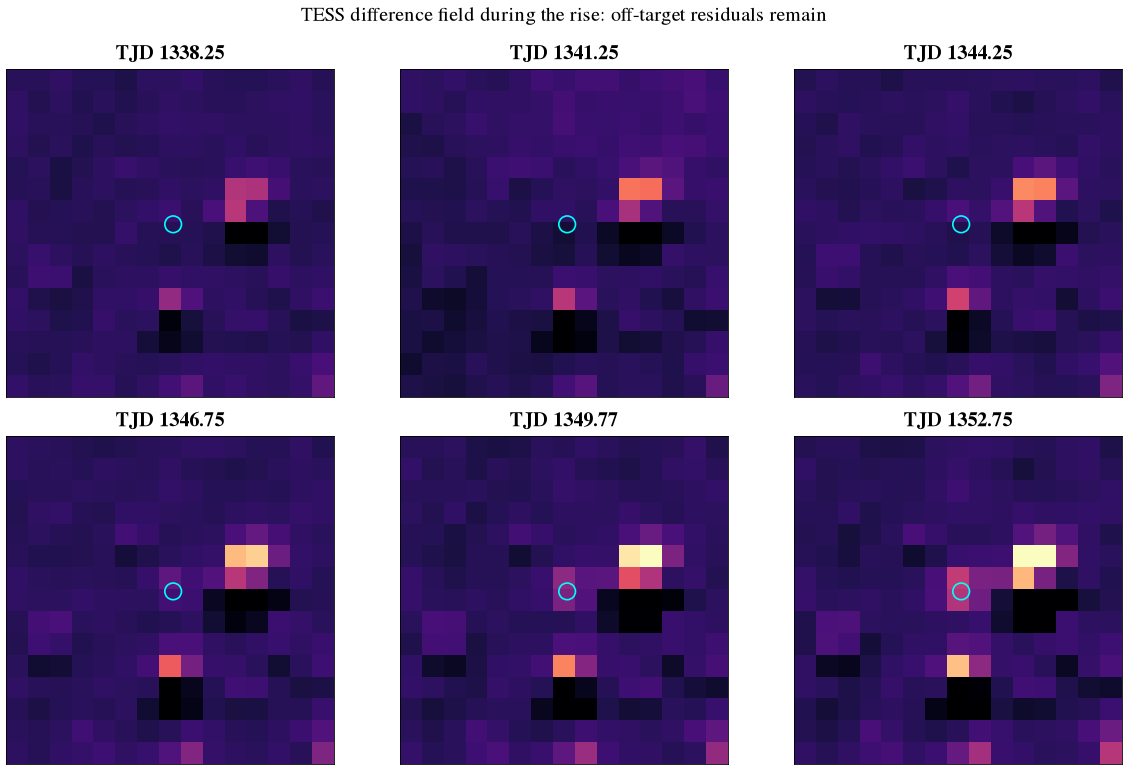

In [4]:
pick=np.linspace(0,len(frames)-1,6,dtype=int); fig,axes=plt.subplots(2,3,figsize=(10,6.6))
for ax,i in zip(axes.flat,pick):
    ax.imshow(frames[i],origin="lower",cmap="magma",vmin=lo,vmax=hi,interpolation="nearest")
    ax.scatter([7.15],[7.40],s=100,facecolors="none",edgecolors="cyan",lw=1); ax.set(title=f"TJD {times[i]:.2f}",xticks=[],yticks=[])
fig.suptitle("TESS difference field during the rise: off-target residuals remain"); fig.tight_layout(); fig.savefig("tess_rise_montage.png"); plt.show()

## Independent check or stress test

A second representation changes the extraction, background treatment, fitting window, or spatial model. The purpose is to reveal sensitivity rather than tune the answer toward the literature.

In [5]:
images=[]
with tempfile.TemporaryDirectory() as tmp:
    tmp=Path(tmp)
    for j,(im,t) in enumerate(zip(frames,times)):
        fig,ax=plt.subplots(figsize=(5,5)); ax.imshow(im,origin="lower",cmap="magma",vmin=lo,vmax=hi,interpolation="nearest")
        ax.scatter([7.15],[7.40],s=180,facecolors="none",edgecolors="cyan",lw=1.3); ax.set(title=f"ASASSN-18tb field | TESS Sector 1 | TJD {t:.2f}",xticks=[],yticks=[])
        fig.tight_layout(); path=tmp/f"frame_{j:03d}.png"; fig.savefig(path,dpi=110); plt.close(fig); images.append(Image.open(path).convert("P"))
    images[0].save("asassn18tb_tess_rise.gif",save_all=True,append_images=images[1:],duration=150,loop=0,optimize=True)
print("Saved animated GIF for direct playback on GitHub")

Saved animated GIF for direct playback on GitHub


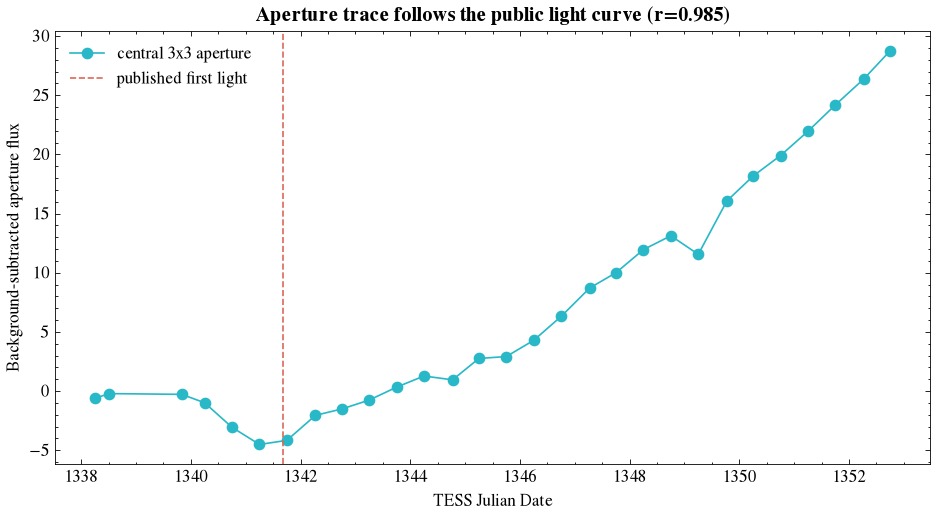

In [6]:
central=np.nansum(frames[:,6:9,6:9],axis=(1,2)); lc["corrected"]=lc.cts-lc.bkg_model; lc["corrected"]-=lc.loc[lc.TJD.between(1327.5,1338),"corrected"].mean(); public=np.interp(times,lc.TJD,lc.corrected); movie_r=stats.pearsonr(central,public).statistic
movie_table=pd.DataFrame({"tjd":times,"central_3x3_background_subtracted":central,"mit_difference_flux":public}); movie_table.to_csv("movie_frame_brightness.csv",index=False)
fig,ax=plt.subplots(figsize=(8,4.5)); ax.plot(times,central,"o-",color=COLORS["cyan"],label="central 3x3 aperture"); ax.axvline(1341.68,ls="--",color=COLORS["coral"],label="published first light")
ax.set(xlabel="TESS Julian Date",ylabel="Background-subtracted aperture flux",title=f"Aperture trace follows the public light curve (r={movie_r:.3f})"); ax.legend(); fig.tight_layout(); fig.savefig("movie_brightness_trace.png"); plt.show()

## Interpretation

The result is limited to this public product and stated reduction. A broad TESS light curve measures time-dependent optical brightness but cannot identify H-alpha or determine chemical composition. DES colours describe the pre-explosion host field. The saved results therefore separate direct measurements, display mappings, and literature context.

In [7]:
FOLDER="2026-08-01-asassn18tb-tess-animation"; TITLE="A real TESS field movie during a supernova rise"; QUESTION="What can raw TESS cutouts show, and where do simple difference images fail to isolate the supernova?"; SAMPLE_SIZE=len(s1_time)
RESULTS=[f"{len(s1_time)} Sector 1 cadences form {len(frames)} half-day movie frames",f"The central aperture trace correlates with the public light curve at r={movie_r:.3f}","Stronger off-target residuals show that the simple movie does not cleanly isolate the supernova","A directly playable animated GIF is saved"]
VALIDATION="Fixed display limits, the WCS target marker, and a separately plotted aperture trace distinguish a measured rise from off-target image residuals."
FIGURES=["tess_rise_montage.png","movie_brightness_trace.png"]; ARTIFACTS=["movie_frame_brightness.csv","asassn18tb_tess_rise.gif"]
CLAIM="Real detector-image diagnostic sequence"; CHECKS=[{"name":"quality-zero frame selection","status":"passed"},{"name":"fixed animation scale","status":"passed"},{"name":"off-target residual check","status":"passed"}]
LIMITS=["TESS pixels blend the host and nearby sources.","The animation covers the Sector 1 rise, not the full decline."]

## Literature validation and limits

- Vallely et al. (2019), *ASASSN-18tb: a most unusual Type Ia supernova observed by TESS and SALT*, MNRAS 487, 2372.
- Fausnaugh et al. (2019), early Type Ia supernova light curves observed by TESS.
- Fausnaugh et al. (2023), four years of TESS Type Ia supernova light curves.
- Brasseur et al. (2019), Astrocut/TESSCut.
- Abbott et al. (2021), Dark Energy Survey Data Release 2.

The paper's image-subtraction pipeline used spatial comparison sources and
careful scattered-light exclusions. Our compact checks cannot reproduce every
pipeline choice. Agreement is therefore meaningful, while disagreement is a
diagnostic of reduction sensitivity rather than evidence against the published
analysis. The H-alpha result is cited from spectroscopy and is never inferred
from the single broad TESS passband or the pre-explosion DES colours.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"MAST / TESS / DES","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Time-domain audit",
"claim_type":CLAIM,"provenance":["MAST TESSCut SPOC FFI cutouts, Sectors 1 and 2",
"MIT TESS Transients cleaned light curve for SN 2018fhw","DES DR2 g/r/i HiPS FITS cutouts via CDS"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
